# CARD-SEQUENCE deck — can play-style survive on *public* logs alone?

**One notebook that asks a single question:** the V1–V4 metrics were built from SabberStone's full
verbose trace (board, attacks, damage, hand, draws, hero power). But a *real* hearthstonemap log —
and our `sim_games` re-emission of it — only carries the **public play sequence**: which card was
played, on which turn, by whom. How much of the play-style signal can we still recover?

### Story arc
*The metrics reconstruct and they do flag aggro (C1, C2) → but every one of them encodes the **deck**
more than the **style** (C3, C4) → within a single deck, pooling games still sharpens the five styles
(C5, C6) → yet across decks the fingerprint does **not** transfer (C7), and the standard domain-shift fix,
deck-normalization, only partially helps because several card-sequence features are **reversed** across
decks rather than merely shifted (C8, C9). The deck-agnostic signal that gave V4 its cross-deck edge —
combat and board — is exactly what card sequences cannot see.*

### How this deck is built
All figures render from **one parse** using the repo-root module
[`cardseq_metrics.py`](../cardseq_metrics.py) (`build_feature_frame` + `discriminativeness`), over the
**8,988** games of `dataset/hearthstonemap_sim/sim_games.json` (5 styles × 2 decks, ~900 each).

| # | Figure | What it shows |
|---|--------|---------------|
| **C1** | Metric inventory | 22 V1–V4 metrics survive (mana/timing/type) + 9 new sequence/relational; ~30 board/combat/hand/draw/hero-power metrics are lost |
| **C2** | Play-style fingerprints (z-score) | what each style looks like in card-sequence metrics (home deck) |
| **C3 ★** | Style signal vs deck leakage | normalized MI (uncertainty coeff) with style vs with deck — **every feature leaks deck > style** |
| **C4** | The dichotomy | U_style vs U_deck scatter — *how fast/much you play* ≈ style; *what you play* ≈ deck |
| **C5** | Per-game, both decks | the dominant axis of card-seq variation is the deck (KMeans recovers deck, not style) |
| **C6** | Within-deck aggregation | pool N games → the 5 styles still separate within one deck (ARI vs N) |
| **C7 ★** | Cross-deck transfer | within-deck accuracy is real, cross-deck collapses to chance (~0.20); pooling can't fix it |
| **C8** | Deck-normalization | the R6c per-deck z-score fix gives **no** cross-deck rescue here (even hurts Warrior→Mage) |
| **C9 ★** | Why + partial fix | many features are *reversed* across decks; deck-norm **+ keeping only consistent features** gives partial traction |

> **Contrast with [`playstyle_SHOW_deck.ipynb`](playstyle_SHOW_deck.ipynb):** that deck used the full
> engine trace and found within-deck fingerprints sharpen with N but stay deck-entangled. This deck
> shows that with *card sequences only*, the entanglement is total — cross-deck transfer is at chance.

## 0 · Setup — one parse feeds every figure

Imports `cardseq_metrics` from the repo root, builds the per-game feature frame (using the on-disk
cache `dataset/hearthstonemap_sim/cardseq_out/cardseq_features.pkl` — delete it to force a re-parse),
runs the per-feature discriminativeness once (`rank`), and defines the shared feature groupings,
colours and helpers (`prep`, `cluster_confusion`) used by every figure below.

In [9]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- anchor to the repo root (holds cardseq_metrics.py) regardless of kernel CWD ---
def _repo_root():
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "cardseq_metrics.py")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise FileNotFoundError("repo root with cardseq_metrics.py not found from " + os.getcwd())
        d = parent
ROOT = _repo_root()
sys.path.insert(0, ROOT)
from cardseq_metrics import build_feature_frame, discriminativeness, OUT_DIR, FEATURES, FEATURE_ORIGIN

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200, "display.max_columns", 40)

STYLE_ORDER  = ["aggro", "control", "fatigue", "midrange", "ramp"]
STYLE_COLORS = dict(zip(STYLE_ORDER, ["#d62728", "#1f77b4", "#9467bd", "#2ca02c", "#ff7f0e"]))
DECK_HOME    = "RenoKazakusMage"

df = build_feature_frame(cache=os.path.join(OUT_DIR, "cardseq_features.pkl"))
df["style"] = pd.Categorical(df["style"], categories=STYLE_ORDER, ordered=True)
games_home  = df[df["deck"] == DECK_HOME].copy()

# feature groupings
SURVIVING   = [f for f in FEATURES if FEATURE_ORIGIN[f][0] == "surviving"]
NEW         = [f for f in FEATURES if FEATURE_ORIGIN[f][0] in ("new", "relational")]
# drop the two near-constant bookkeeping columns from the multivariate matrix
ANALYSIS_FEATURES = [f for f in FEATURES if f not in ("has_coin", "coin_turn")]

# a coarse "family" per feature (used to colour C4)
FAMILY = {}
for f in FEATURES:
    if f in ("n_cards", "n_my_turns", "mana_spent", "cards_per_turn"):                       FAMILY[f] = "volume/length"
    elif f.startswith("mana_eff") or f in ("mana_eff", "mana_per_turn", "mana_floated_per_turn",
                                           "mana_slope", "plays_per_turn_cv"):                FAMILY[f] = "tempo"
    elif f in ("first_play_turn", "first_minion_turn", "first_minion_frac", "front_load",
               "coin_turn", "has_coin"):                                                     FAMILY[f] = "timing"
    elif f in ("minion_fraction", "spell_fraction", "weapon_fraction"):                      FAMILY[f] = "composition"
    elif f in ("avg_card_cost", "max_card_cost", "cost_tilt"):                               FAMILY[f] = "cost"
    elif f in ("card_name_entropy", "mana_cost_entropy", "distinct_card_ratio", "max_card_repeat"): FAMILY[f] = "diversity"
    else:                                                                                    FAMILY[f] = "relational"
FAM_ORDER  = ["volume/length", "tempo", "timing", "composition", "cost", "diversity", "relational"]
FAM_COLORS = dict(zip(FAM_ORDER, sns.color_palette("tab10", len(FAM_ORDER))))

def prep(frame, feats=None, fit_from=None):
    """median-impute (from `fit_from` or self) + z-score. Returns (X, style[], deck[])."""
    from sklearn.preprocessing import StandardScaler
    feats = feats or ANALYSIS_FEATURES
    med = (frame if fit_from is None else fit_from)[feats].median()
    Xr  = frame[feats].fillna(med)
    scaler = StandardScaler().fit((fit_from if fit_from is not None else frame)[feats].fillna(med).values)
    return (scaler.transform(Xr.values),
            frame["style"].astype(str).values, frame["deck"].astype(str).values)

from scipy.optimize import linear_sum_assignment
def cluster_confusion(true_lab, clab, order=STYLE_ORDER):
    k = len(order)
    M = pd.crosstab(pd.Series(true_lab, name="style"), pd.Series(clab, name="cluster"))
    M = M.reindex(index=order).reindex(columns=range(k), fill_value=0).fillna(0)
    r, c = linear_sum_assignment(-M.values)
    col_to_style = {c[i]: order[r[i]] for i in range(len(r))}
    mapped = pd.Series(clab).map(lambda x: col_to_style.get(x, x)).values
    cm = pd.crosstab(pd.Series(true_lab, name="true style"),
                     pd.Series(mapped, name="cluster->style")).reindex(index=order, columns=order, fill_value=0)
    return cm, mapped

# one discriminativeness pass (KW + eps2 + normalized MI vs style AND deck)
rank, STYLES = discriminativeness(df)

print(f"df {df.shape}  |  home deck '{DECK_HOME}' -> games_home {games_home.shape}")
print(f"surviving-from-V1-V4: {len(SURVIVING)}   new (seq/relational): {len(NEW)}   analysis matrix: {len(ANALYSIS_FEATURES)}")
print("\ngames per deck/style:")
print(df.groupby(["deck", "style"], observed=True).size().to_string())

df (8988, 35)  |  home deck 'RenoKazakusMage' -> games_home (4488, 35)
surviving-from-V1-V4: 22   new (seq/relational): 9   analysis matrix: 29

games per deck/style:
deck                style   
AggroPirateWarrior  aggro       900
                    control     900
                    fatigue     900
                    midrange    900
                    ramp        900
RenoKazakusMage     aggro       899
                    control     897
                    fatigue     898
                    midrange    899
                    ramp        895


## C1 · Metric inventory — what survives, what's new, what's lost

* **Left:** the **31 card-sequence metrics** this study computes, split by family and coloured by
  origin — 22 are the mana / timing / card-type subset of the V1–V4 metrics that survive *without*
  the engine trace, plus 9 new sequence-structure and relational metrics only visible in the play order.
* **Right:** the V1–V4 metrics that are **lost** because they need signals the card sequence never
  carries — grouped by the missing engine event. This is the price of using public logs.

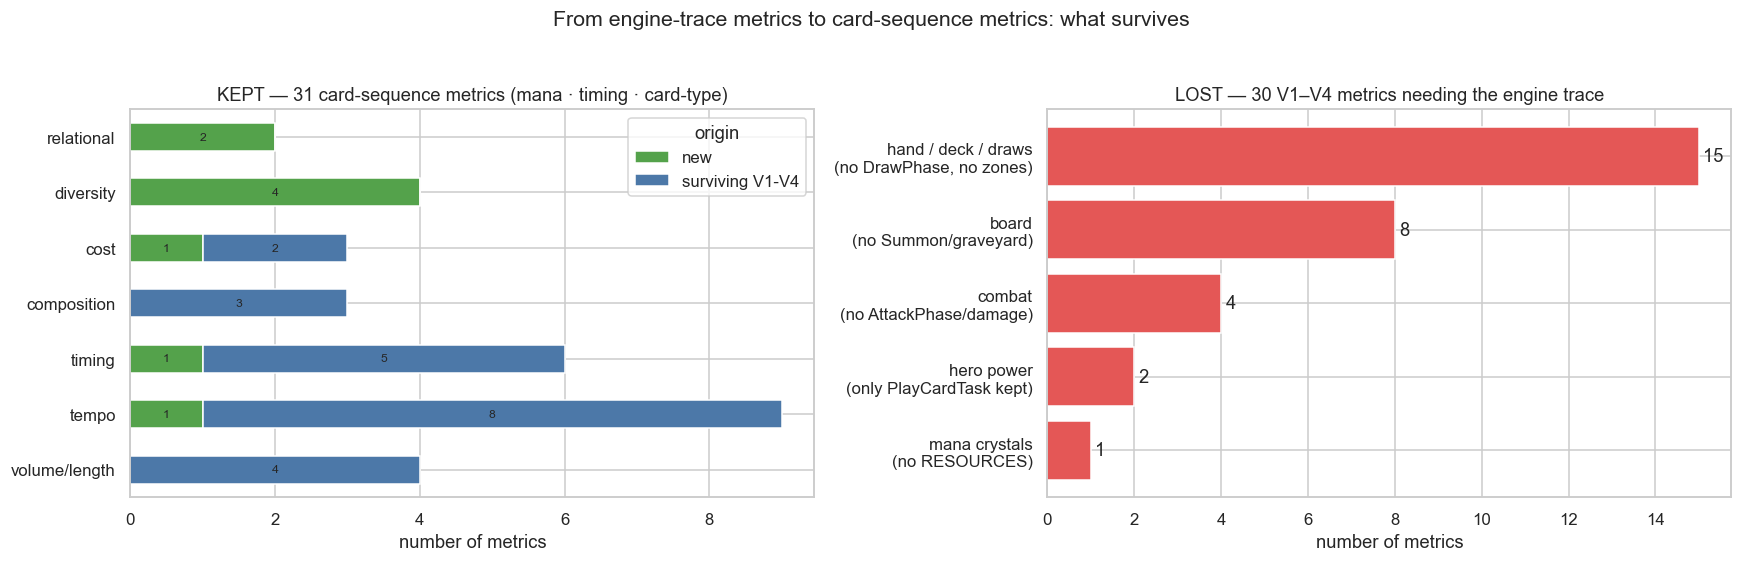

Kept metrics by origin:
origin
new                 9
surviving V1-V4    22


In [10]:
# C1 — metric inventory: kept (by family/origin) vs lost (by required engine signal)
kept = pd.DataFrame({"feature": FEATURES,
                     "family": [FAMILY[f] for f in FEATURES],
                     "origin": ["surviving V1-V4" if FEATURE_ORIGIN[f][0] == "surviving" else "new"
                                for f in FEATURES]})
piv = (kept.groupby(["family", "origin"]).size().unstack("origin", fill_value=0)
       .reindex(FAM_ORDER).fillna(0))

# metrics from V1-V4 that cannot be reconstructed from card plays (grouped by missing signal)
LOST = {
    "hand / deck / draws\n(no DrawPhase, no zones)": ["avg_cards_in_hand", "max_cards_in_hand",
        "hand_fill_ratio", "cards_drawn_per_turn", "cards_left_in_deck", "cards_left_frac",
        "value_turn_fraction", "hand_at_t{3,5,7,9}", "hand_frac_t{3,5,7,9}"],
    "board\n(no Summon/graveyard)": ["avg_board_minions", "avg_enemy_board_minions",
        "enemy_minions_killed_per_turn", "proactive_ratio", "board_at_t{3,5,7,9}"],
    "combat\n(no AttackPhase/damage)": ["face_attack_ratio", "attacks_per_turn",
        "face_dmg_per_turn", "taken_dmg_per_turn"],
    "hero power\n(only PlayCardTask kept)": ["hp_uses", "hp_per_turn"],
    "mana crystals\n(no RESOURCES)": ["extra_mana_crystals"],
}
def _count(items):   # expand the {3,5,7,9} shorthand to 4 columns each
    return sum(4 if "{3,5,7,9}" in it else 1 for it in items)
lost_counts = pd.Series({k: _count(v) for k, v in LOST.items()}).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(16, 5.2))
piv.plot.barh(stacked=True, ax=ax[0], color={"surviving V1-V4": "#4C78A8", "new": "#54A24B"})
ax[0].set_title(f"KEPT — {len(FEATURES)} card-sequence metrics (mana · timing · card-type)")
ax[0].set_xlabel("number of metrics"); ax[0].set_ylabel("")
for cont in ax[0].containers:
    ax[0].bar_label(cont, label_type="center", fontsize=8,
                    labels=[int(v) if v else "" for v in cont.datavalues])
ax[1].barh(lost_counts.index, lost_counts.values, color="#E45756")
ax[1].bar_label(ax[1].containers[0], padding=3)
ax[1].set_title(f"LOST — {int(lost_counts.sum())} V1–V4 metrics needing the engine trace")
ax[1].set_xlabel("number of metrics")
fig.suptitle("From engine-trace metrics to card-sequence metrics: what survives", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

print("Kept metrics by origin:")
print(kept.groupby("origin").size().to_string())

## C2 · Play-style fingerprints — per-style mean of each metric (z-score)

* **From:** home deck `RenoKazakusMage`, the surviving + new card-sequence metrics.
* **Why a slide:** the interpretable *"what a style looks like"* view, restricted to what public logs
  can see. Colour = σ from the 5-style average; annotations are raw means. **aggro** is the loud row
  (few cheap cards, low mana/turn, short game, high tempo burstiness); control / fatigue / midrange /
  ramp are much closer together — the first hint that card sequences mostly separate *aggro vs the rest*.

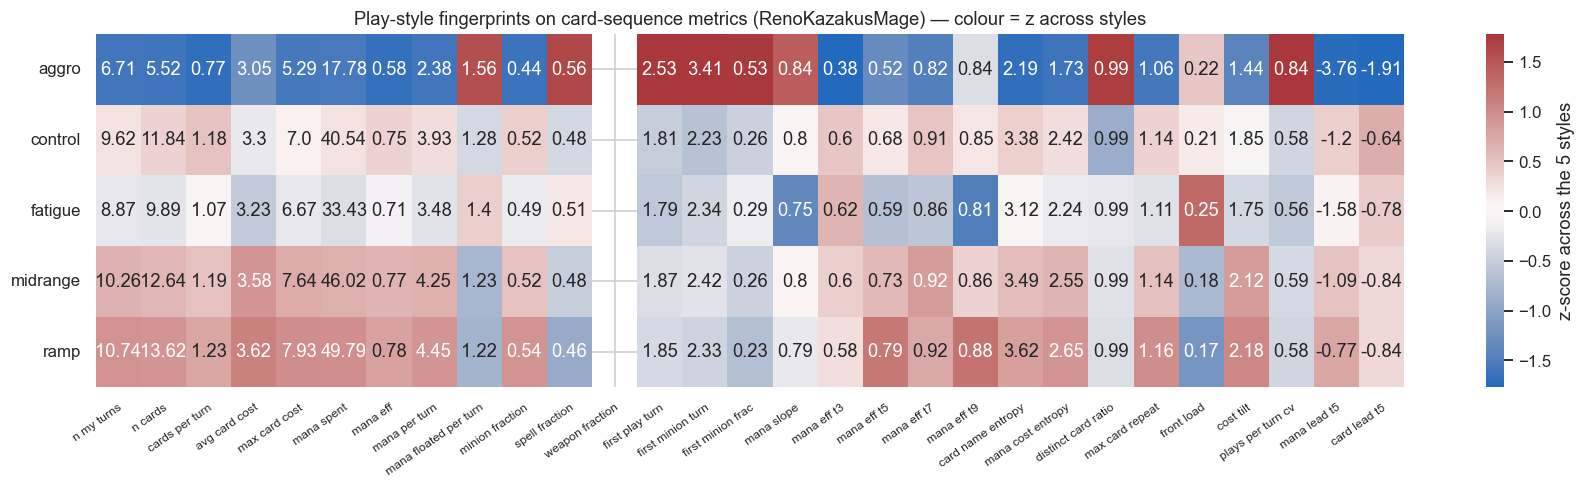

In [11]:
# C2 — play-style fingerprints on card-sequence metrics (home deck), z-scored across styles
FP_FEATS = [f for f in ANALYSIS_FEATURES]      # all analysis features
mean_tbl = games_home.groupby("style", observed=True)[FP_FEATS].mean().reindex(STYLE_ORDER)
z = (mean_tbl - mean_tbl.mean()) / mean_tbl.std()

fig, ax = plt.subplots(figsize=(16, 4.6))
sns.heatmap(z, annot=mean_tbl.round(2), fmt="", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "z-score across the 5 styles"})
ax.set_title(f"Play-style fingerprints on card-sequence metrics ({DECK_HOME}) — colour = z across styles")
ax.set_ylabel("")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
ax.set_xticklabels([t.get_text().replace("_", " ") for t in ax.get_xticklabels()],
                   rotation=35, ha="right", rotation_mode="anchor", fontsize=8)
fig.tight_layout(); plt.show()

## C3 ★ · Style signal vs deck leakage — normalized mutual information

* **From:** all 8,988 games; `discriminativeness()` in `cardseq_metrics.py`.
* **Metric:** mutual information is in nats, and its ceiling differs by target (H(style)=ln5 ≠ H(deck)=ln2),
  so raw MI is not comparable across targets. We normalize each by its target entropy → the
  **uncertainty coefficient** `U = I(feature; label) / H(label)` ∈ [0,1] = the fraction of that label's
  uncertainty the feature explains.
* **Why a slide (the headline):** **every single feature explains more of the DECK (red) than the
  STYLE (blue).** Composition/cost/diversity features (`spell_fraction`, `max_card_cost`,
  `mana_cost_entropy`, `minion_fraction`) are near-pure deck identity; volume/timing features
  (`n_cards`, `n_my_turns`, `first_minion_frac`) leak the least. There is no feature with U_gap > 0.

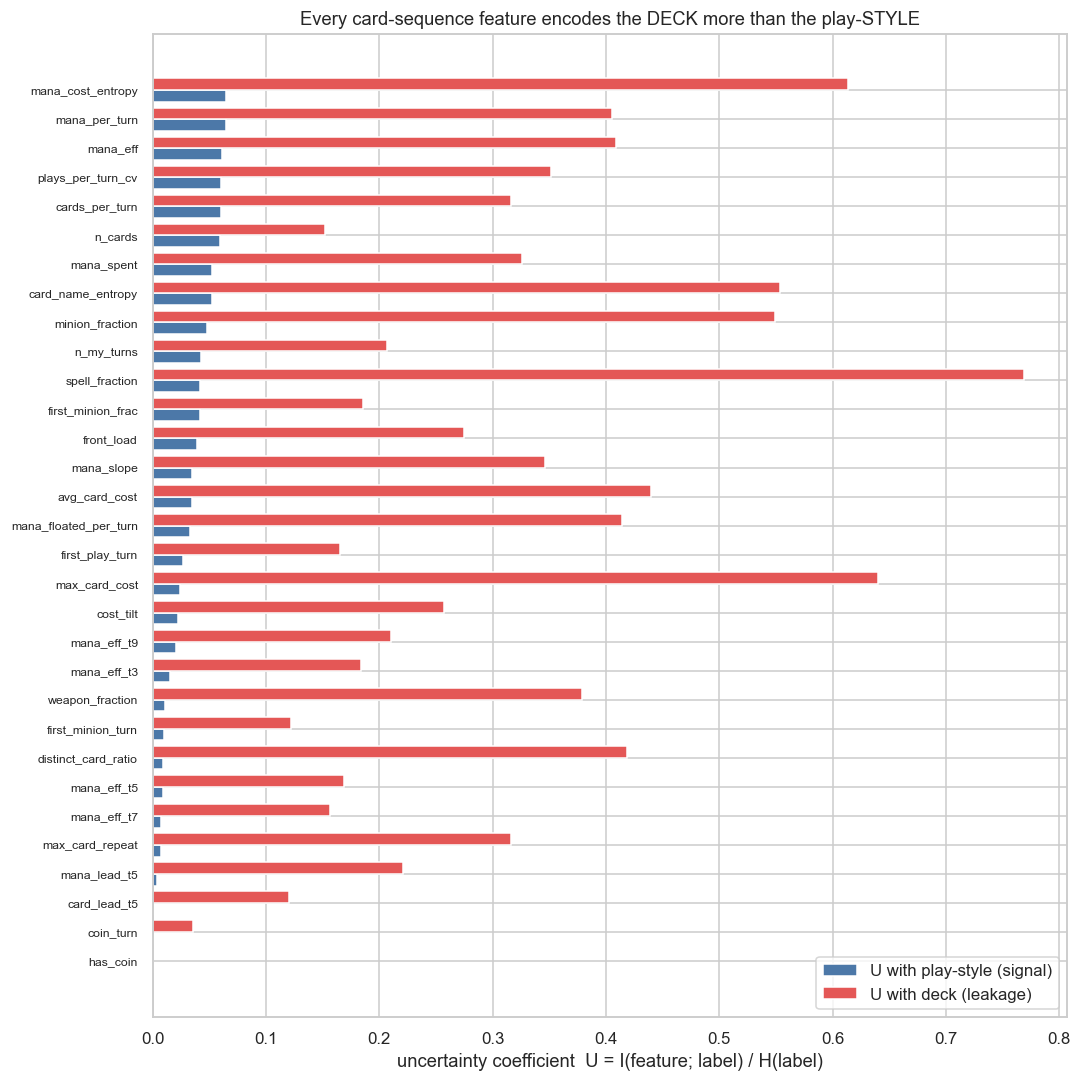

Top style-signal features (by U_style): mana_cost_entropy, mana_per_turn, mana_eff, plays_per_turn_cv, cards_per_turn, n_cards
Worst deck-leakers (by U_deck): spell_fraction, max_card_cost, mana_cost_entropy, card_name_entropy, minion_fraction, avg_card_cost


In [12]:
# C3 — normalized MI with style (signal) vs with deck (leakage), per feature
r = rank.sort_values("U_style")
y = np.arange(len(r))
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y - 0.2, r["U_style"], height=0.4, label="U with play-style (signal)", color="#4C78A8")
ax.barh(y + 0.2, r["U_deck"],  height=0.4, label="U with deck (leakage)",       color="#E45756")
ax.set_yticks(y); ax.set_yticklabels(r["feature"], fontsize=8)
ax.set_xlabel("uncertainty coefficient  U = I(feature; label) / H(label)")
ax.set_title("Every card-sequence feature encodes the DECK more than the play-STYLE")
ax.legend(loc="lower right"); fig.tight_layout(); plt.show()

print("Top style-signal features (by U_style):",
      ", ".join(rank.head(6)["feature"]))
print("Worst deck-leakers (by U_deck):",
      ", ".join(rank.sort_values("U_deck", ascending=False).head(6)["feature"]))

## C4 · The dichotomy — *how much you play* ≈ style, *what you play* ≈ deck

* **From:** the same `rank` table; each point is a feature.
* **Axes:** x = U_style (signal), y = U_deck (leakage); marker size ∝ Kruskal–Wallis effect size (ε²);
  colour = feature family. The dashed line is U_deck = U_style — **everything sits above it** (deck-leaning).
* **Read:** the *composition / cost / diversity* families sit high on the deck axis (they describe the
  card pool = the deck). The *volume / length / timing / tempo* families sit lower and furthest right —
  they carry what little transferable style signal exists, because "how fast and how much you commit"
  is a behavioural tell, not a deck-list fact.

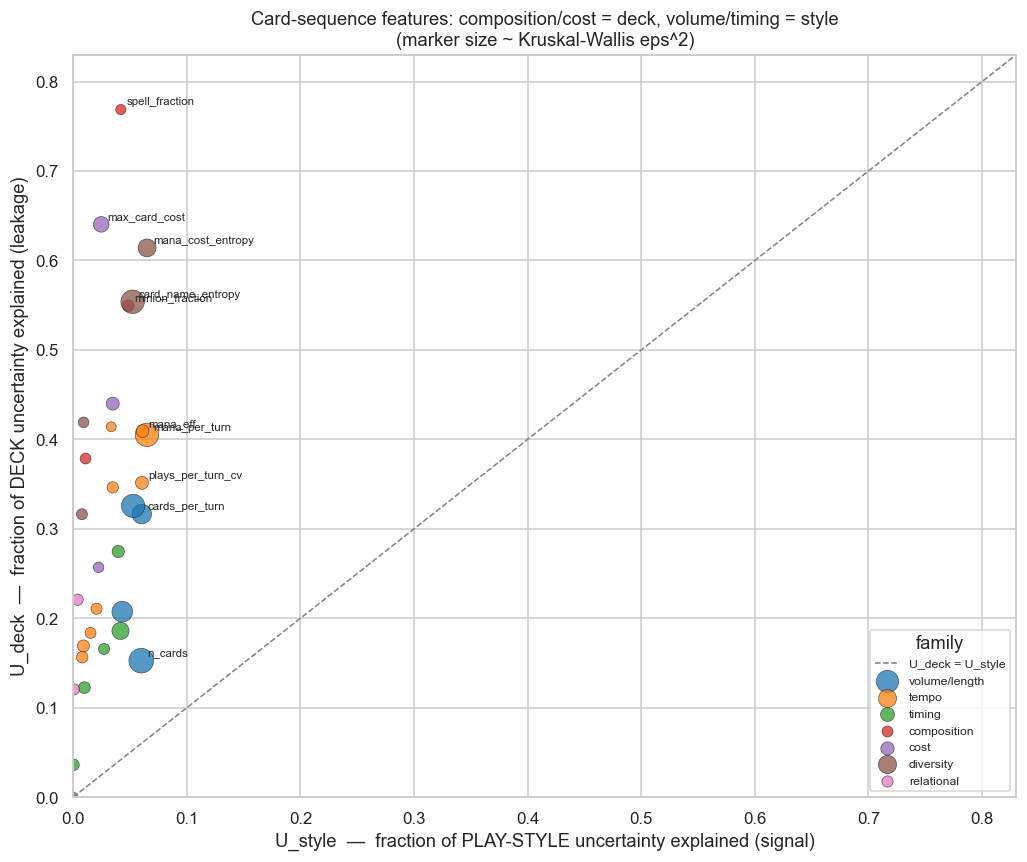

In [13]:
# C4 — U_style vs U_deck scatter, coloured by family, sized by effect size (eps2)
r = rank.copy()
r["family"] = r["feature"].map(FAMILY)
fig, ax = plt.subplots(figsize=(9.5, 8))
lim = max(r["U_style"].max(), r["U_deck"].max()) * 1.08
ax.plot([0, lim], [0, lim], "--", color="gray", lw=1, label="U_deck = U_style")
for fam in FAM_ORDER:
    s = r[r["family"] == fam]
    ax.scatter(s["U_style"], s["U_deck"], s=40 + 1400 * s["eps2"].clip(lower=0),
               color=FAM_COLORS[fam], alpha=.75, edgecolor="k", linewidth=.4, label=fam)
# label the most informative / most leaky features
for _, row in pd.concat([r.nlargest(6, "U_style"), r.nlargest(5, "U_deck")]).drop_duplicates("feature").iterrows():
    ax.annotate(row["feature"], (row["U_style"], row["U_deck"]), fontsize=7.5,
                xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("U_style  —  fraction of PLAY-STYLE uncertainty explained (signal)")
ax.set_ylabel("U_deck  —  fraction of DECK uncertainty explained (leakage)")
ax.set_title("Card-sequence features: composition/cost = deck, volume/timing = style\n(marker size ~ Kruskal-Wallis eps^2)")
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.legend(fontsize=8, title="family"); fig.tight_layout(); plt.show()

## C5 · Per-game, pooled over both decks — the dominant axis is the DECK

* **From:** all 8,988 games, standardised on the card-sequence features; one PCA, two colourings.
* **Why a slide:** the same points coloured by **deck** (left) fall into two clean blobs, but coloured by
  **style** (middle) they are tangled. The bar (right) makes it quantitative: unsupervised KMeans recovers
  the *deck* almost perfectly (ARI≈, k=2) but the *style* barely above chance (ARI≈, k=5). On card
  sequences, the biggest thing a game tells you is **which deck it is**, not how it was played.

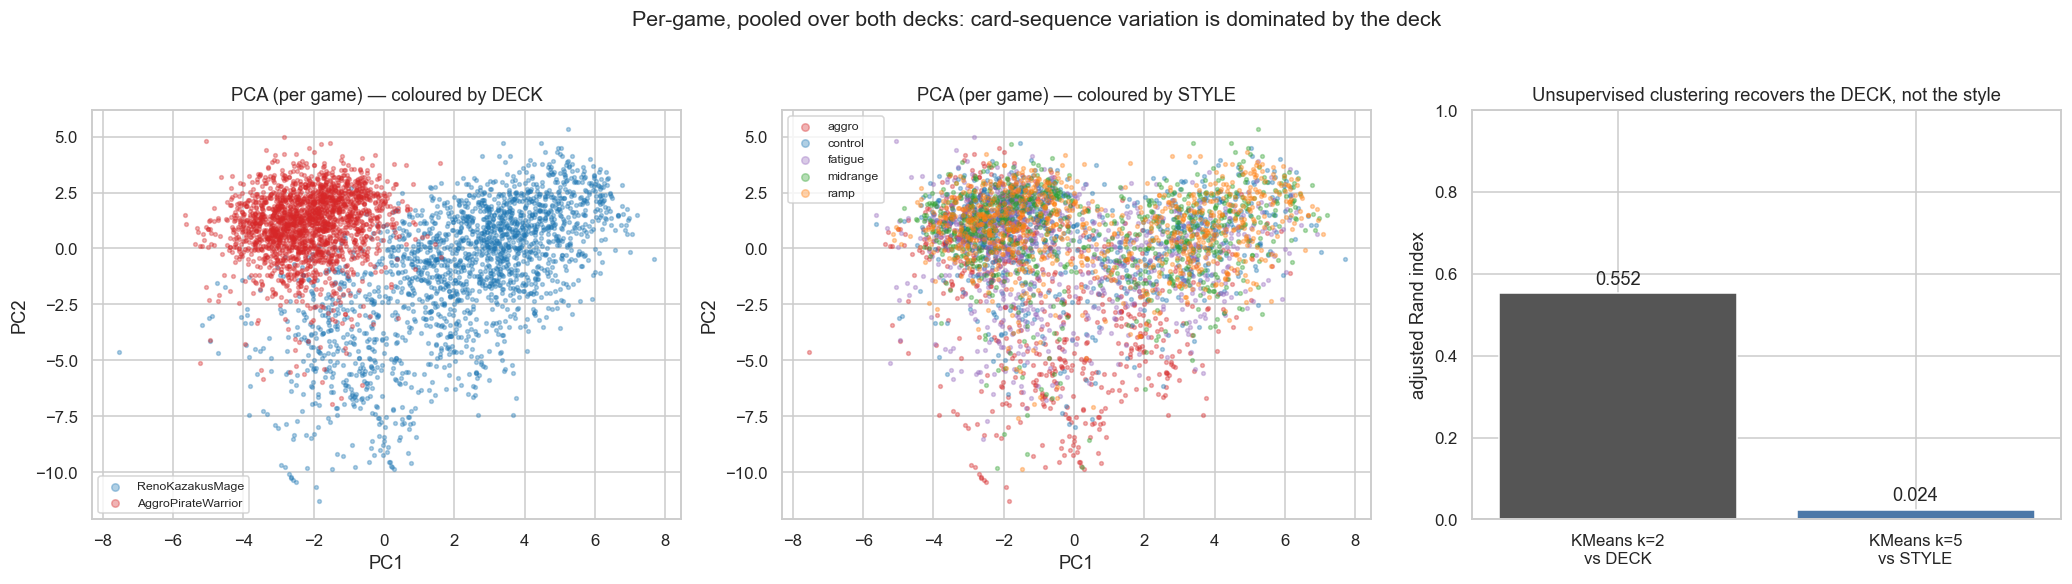

KMeans ARI vs deck (k=2) = 0.552   vs style (k=5) = 0.024


In [14]:
# C5 — pooled per-game PCA coloured by deck vs by style + KMeans ARI to each label
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

Xall, y_style, y_deck = prep(df)
P = PCA(n_components=2, random_state=0).fit_transform(Xall)
rng = np.random.default_rng(0)
sub = rng.choice(len(Xall), size=min(4000, len(Xall)), replace=False)   # subsample for a readable scatter

ari_deck  = adjusted_rand_score(y_deck,  KMeans(2, n_init=10, random_state=0).fit_predict(Xall))
ari_style = adjusted_rand_score(y_style, KMeans(5, n_init=10, random_state=0).fit_predict(Xall))

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
deck_colors = {"RenoKazakusMage": "#1f77b4", "AggroPirateWarrior": "#d62728"}
for dk, col in deck_colors.items():
    m = (y_deck[sub] == dk)
    ax[0].scatter(P[sub][m, 0], P[sub][m, 1], s=6, alpha=.35, color=col, label=dk)
ax[0].set_title("PCA (per game) — coloured by DECK"); ax[0].legend(fontsize=8, markerscale=2)
for st in STYLE_ORDER:
    m = (y_style[sub] == st)
    ax[1].scatter(P[sub][m, 0], P[sub][m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[1].set_title("PCA (per game) — coloured by STYLE"); ax[1].legend(fontsize=8, markerscale=2)
for a in ax[:2]:
    a.set_xlabel("PC1"); a.set_ylabel("PC2")
ax[2].bar(["KMeans k=2\nvs DECK", "KMeans k=5\nvs STYLE"], [ari_deck, ari_style],
          color=["#555555", "#4C78A8"])
ax[2].bar_label(ax[2].containers[0], fmt="%.3f", padding=3)
ax[2].set_ylabel("adjusted Rand index"); ax[2].set_ylim(0, 1)
ax[2].set_title("Unsupervised clustering recovers the DECK, not the style")
fig.suptitle("Per-game, pooled over both decks: card-sequence variation is dominated by the deck", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print(f"KMeans ARI vs deck (k=2) = {ari_deck:.3f}   vs style (k=5) = {ari_style:.3f}")

## C6 · Within one deck, pooling games still sharpens the 5 styles

* **From:** home deck `RenoKazakusMage` only; bootstrap N-game fingerprints per style → KMeans(k=5) ARI.
* **Why a slide (the silver lining):** hold the deck fixed and the card-sequence metrics *do* carry style —
  as N games are averaged into a player fingerprint, cluster–style ARI climbs well above the per-game
  value. So the metrics are not noise; the problem in C3–C5 is **bias (the deck), not variance**. This is
  the within-deck analogue of the engine-trace deck's headline — the difference is what happens across decks (C7).

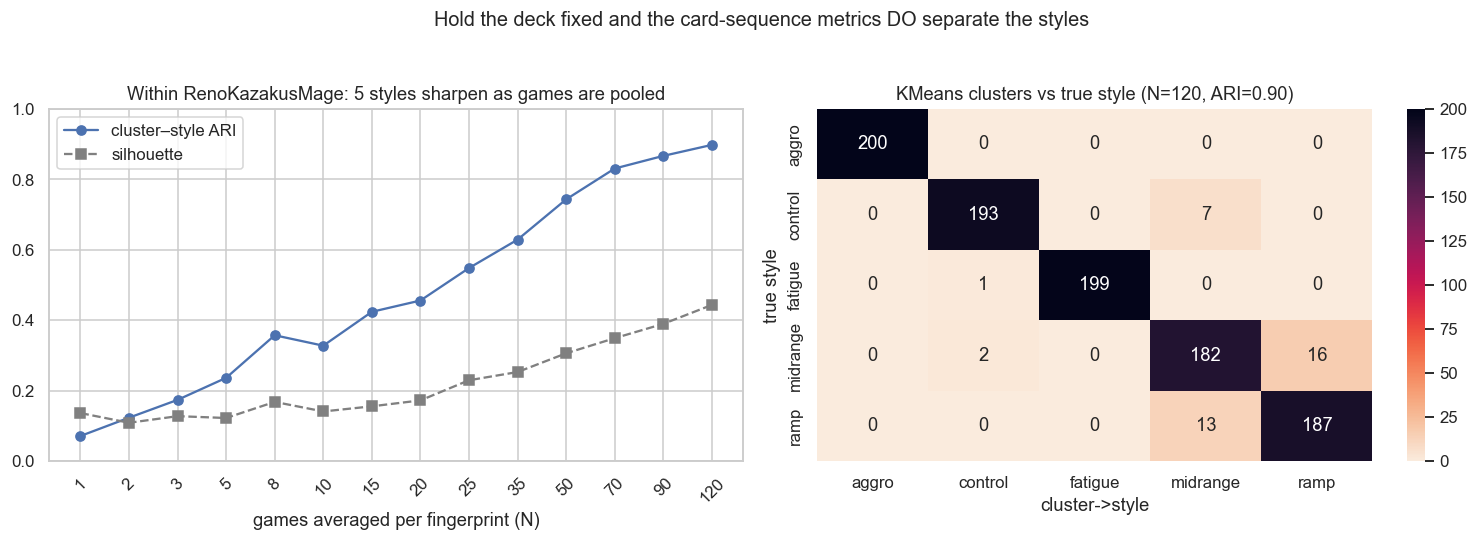

within-deck KMeans ARI:  N=1 -> 0.071   N=120 -> 0.898


In [15]:
# C6 — within home deck: ARI of KMeans(k=5) on N-game fingerprints, vs N
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

Xh, yh, _ = prep(games_home)
by = {s: Xh[yh == s] for s in STYLE_ORDER}
def fingerprints(N, reps=150, seed=0):
    rng = np.random.default_rng(seed); rows, lab = [], []
    for s in STYLE_ORDER:
        a = by[s]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(0)); lab.append(s)
    return np.array(rows), np.array(lab)

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 120]
aris, sils = [], []
for N in Ns:
    Xb, yb = fingerprints(N)
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    aris.append(adjusted_rand_score(yb, lab)); sils.append(silhouette_score(Xb, lab))

Xb, yb = fingerprints(120, reps=200)
labb = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
cmb, _ = cluster_confusion(yb, labb)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
xs = range(len(Ns))
ax[0].plot(xs, aris, "o-", label="cluster–style ARI")
ax[0].plot(xs, sils, "s--", color="gray", label="silhouette")
ax[0].set_xticks(list(xs)); ax[0].set_xticklabels(Ns, rotation=45); ax[0].set_ylim(0, 1)
ax[0].set_xlabel("games averaged per fingerprint (N)")
ax[0].set_title(f"Within {DECK_HOME}: 5 styles sharpen as games are pooled"); ax[0].legend()
sns.heatmap(cmb, annot=True, fmt="d", cmap="rocket_r", ax=ax[1])
ax[1].set_title(f"KMeans clusters vs true style (N=120, ARI={aris[-1]:.2f})")
fig.suptitle("Hold the deck fixed and the card-sequence metrics DO separate the styles", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print(f"within-deck KMeans ARI:  N=1 -> {aris[0]:.3f}   N=120 -> {aris[-1]:.3f}")

## C7 ★ · The clincher — within-deck works, cross-deck collapses to chance

* **From:** both decks; LDA on N-game fingerprints, scored by **accuracy** (5 balanced styles → chance 0.20).
* **Left:** within-deck (train & test the *same* deck) reaches high accuracy (~0.5–0.76), but **cross-deck**
  (train one deck, test the other) falls close to chance in both directions (~0.25–0.28 vs chance 0.20) —
  a style classifier learned on Mage is nearly useless on Warrior and vice-versa.
* **Right:** accuracy vs games pooled. Within-deck rises with N; **cross-deck stays flat near chance** — you
  cannot average your way out, because the failure is deck bias, not noise. (A single-game RandomForest
  agrees even more starkly: ≈0.36 within-deck overall, ≈0.19 cross-deck — chance.)
* **Conclusion:** on public card sequences, play-style is *entirely* deck-entangled. The transferable signal
  V4 relied on — combat/board behaviour — is exactly what the card sequence cannot observe.

Accuracy of an LDA on N=10 fingerprints (chance = 0.20):
  within Mage      0.759
  within Warrior   0.505
  cross M->W       0.252
  cross W->M       0.277


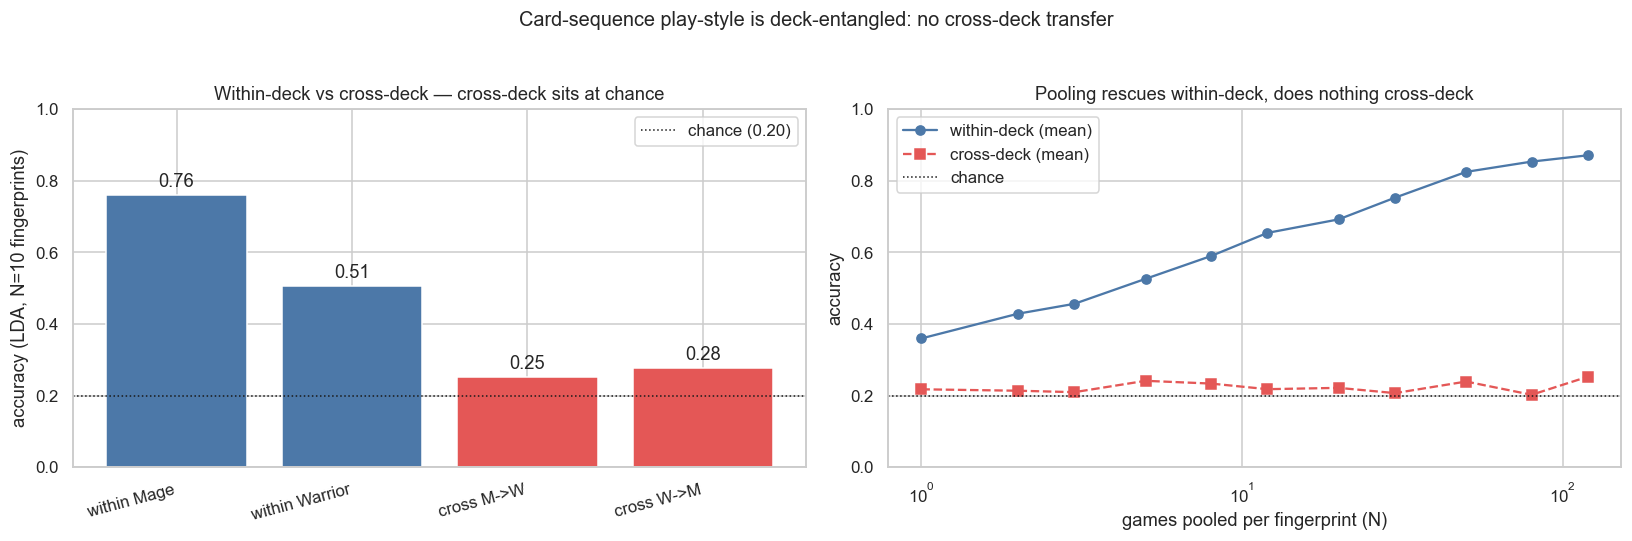

In [16]:
# C7 — within-deck vs cross-deck accuracy of an LDA on N-game fingerprints
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

DA, DB = "RenoKazakusMage", "AggroPirateWarrior"

def _fps(by, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = by[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

def within_acc(deck, N=10, reps=300):
    d = df[df["deck"] == deck]
    X, y, _ = prep(d)
    rng = np.random.default_rng(0); trby, teby = {}, {}
    for s in STYLE_ORDER:
        idx = np.where(y == s)[0]; rng.shuffle(idx); h = len(idx) // 2
        trby[s], teby[s] = X[idx[:h]], X[idx[h:]]
    Xa, ya = _fps(trby, N, reps, 10); Xb, yb = _fps(teby, N, reps, 20)
    return (LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb) == yb).mean()

def cross_acc(a, b, N=10, reps=300):
    tr, te = df[df["deck"] == a], df[df["deck"] == b]
    Xtr, ytr, _ = prep(tr)
    Xte, yte, _ = prep(te, fit_from=tr)            # impute + scale using the TRAIN deck
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    Xa, ya = _fps(trby, N, reps, 10); Xb, yb = _fps(teby, N, reps, 20)
    return (LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb) == yb).mean()

bars = {"within Mage": within_acc(DA), "within Warrior": within_acc(DB),
        "cross M->W": cross_acc(DA, DB), "cross W->M": cross_acc(DB, DA)}
print("Accuracy of an LDA on N=10 fingerprints (chance = 0.20):")
for k, v in bars.items():
    print(f"  {k:16s} {v:.3f}")

Ns = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120]
within_curve = [ (within_acc(DA, N) + within_acc(DB, N)) / 2 for N in Ns ]
cross_curve  = [ (cross_acc(DA, DB, N) + cross_acc(DB, DA, N)) / 2 for N in Ns ]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
colors = ["#4C78A8", "#4C78A8", "#E45756", "#E45756"]
ax[0].bar(list(bars), list(bars.values()), color=colors)
ax[0].bar_label(ax[0].containers[0], fmt="%.2f", padding=3)
ax[0].axhline(0.20, color="k", ls=":", lw=1, label="chance (0.20)")
ax[0].set_ylabel("accuracy (LDA, N=10 fingerprints)"); ax[0].set_ylim(0, 1)
ax[0].set_xticks(range(len(bars))); ax[0].set_xticklabels(list(bars), rotation=15, ha="right")
ax[0].set_title("Within-deck vs cross-deck — cross-deck sits at chance"); ax[0].legend()
ax[1].plot(Ns, within_curve, "o-", color="#4C78A8", label="within-deck (mean)")
ax[1].plot(Ns, cross_curve,  "s--", color="#E45756", label="cross-deck (mean)")
ax[1].axhline(0.20, color="k", ls=":", lw=1, label="chance")
ax[1].set_xscale("log"); ax[1].set_xlabel("games pooled per fingerprint (N)")
ax[1].set_ylabel("accuracy"); ax[1].set_ylim(0, 1)
ax[1].set_title("Pooling rescues within-deck, does nothing cross-deck"); ax[1].legend()
fig.suptitle("Card-sequence play-style is deck-entangled: no cross-deck transfer", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

## C8 · Deck-normalization (the R6c domain-shift fix) — does it rescue transfer?

* **What:** the standard cure for domain shift, and the *first partial fix* in the engine-trace deck
  ([`playstyle_SHOW_deck.ipynb`](playstyle_SHOW_deck.ipynb) R6c): express each game not by its raw
  feature values but by **how far it deviates from the average player of its own deck** — a per-deck
  z-score. This removes each deck's location and scale, so in principle the two decks land in one frame.
* **There it worked:** on the engine-trace features R6c lifted cross-deck ARI from ~0.08 to ~0.44.
* **Here it does not.** On card sequences, per-deck z-scoring leaves cross-deck accuracy at chance and
  actually *hurts* one direction (Warrior→Mage). Pooling more games (right) does not change that — the
  green (normalized) and red (raw) curves both sit near the 0.20 chance line. C9 shows why.

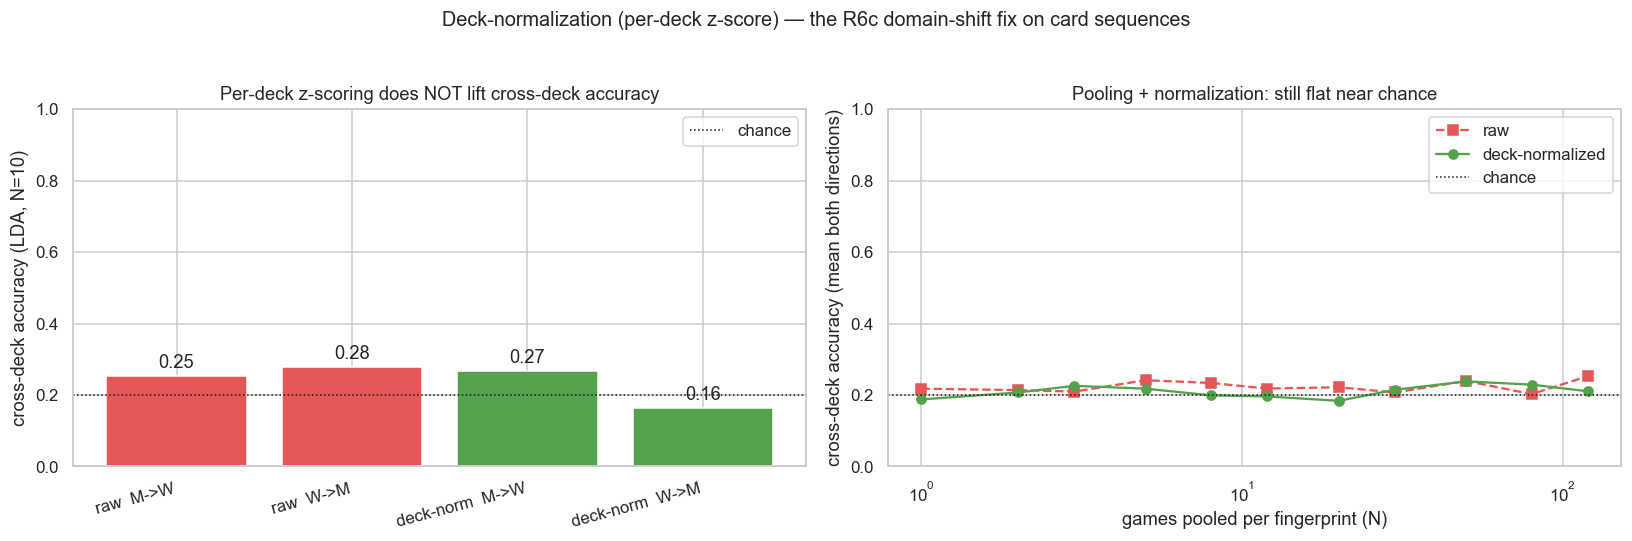

cross-deck accuracy (chance 0.20):
  raw  M->W          0.252
  raw  W->M          0.277
  deck-norm  M->W    0.266
  deck-norm  W->M    0.163


In [17]:
# C8 — deck-normalization (per-deck z-score) vs raw, on cross-deck transfer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
DA, DB = "RenoKazakusMage", "AggroPirateWarrior"

def deck_zscore(frame, feats):
    """Domain-shift correction: within each deck, median-impute then z-score every feature."""
    g = frame.copy()
    g[feats] = g[feats].fillna(g.groupby("deck")[feats].transform("median"))
    g[feats] = g.groupby("deck")[feats].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
    return g
df_dz = deck_zscore(df, FEATURES)

def _fps(by, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = by[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

def cross_feats(frame, a, b, feats=None, N=10, reps=300):
    """train deck a -> test deck b: LDA on N-game fingerprints (impute+scale from TRAIN deck)."""
    feats = feats or ANALYSIS_FEATURES
    tr, te = frame[frame["deck"] == a], frame[frame["deck"] == b]
    Xtr, ytr, _ = prep(tr, feats); Xte, yte, _ = prep(te, feats, fit_from=tr)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    Xa, ya = _fps(trby, N, reps, 10); Xb, yb = _fps(teby, N, reps, 20)
    return (LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb) == yb).mean()

bars = {"raw  M->W": cross_feats(df, DA, DB),   "raw  W->M": cross_feats(df, DB, DA),
        "deck-norm  M->W": cross_feats(df_dz, DA, DB), "deck-norm  W->M": cross_feats(df_dz, DB, DA)}
Ns = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120]
raw_c = [(cross_feats(df, DA, DB, N=N) + cross_feats(df, DB, DA, N=N)) / 2 for N in Ns]
dz_c  = [(cross_feats(df_dz, DA, DB, N=N) + cross_feats(df_dz, DB, DA, N=N)) / 2 for N in Ns]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(range(4), list(bars.values()), color=["#E45756", "#E45756", "#54A24B", "#54A24B"])
ax[0].bar_label(ax[0].containers[0], fmt="%.2f", padding=3)
ax[0].axhline(0.20, color="k", ls=":", lw=1, label="chance")
ax[0].set_xticks(range(4)); ax[0].set_xticklabels(list(bars), rotation=15, ha="right")
ax[0].set_ylim(0, 1); ax[0].set_ylabel("cross-deck accuracy (LDA, N=10)")
ax[0].set_title("Per-deck z-scoring does NOT lift cross-deck accuracy"); ax[0].legend()
ax[1].plot(Ns, raw_c, "s--", color="#E45756", label="raw")
ax[1].plot(Ns, dz_c,  "o-",  color="#54A24B", label="deck-normalized")
ax[1].axhline(0.20, color="k", ls=":", lw=1, label="chance")
ax[1].set_xscale("log"); ax[1].set_xlabel("games pooled per fingerprint (N)")
ax[1].set_ylabel("cross-deck accuracy (mean both directions)"); ax[1].set_ylim(0, 1)
ax[1].set_title("Pooling + normalization: still flat near chance"); ax[1].legend()
fig.suptitle("Deck-normalization (per-deck z-score) — the R6c domain-shift fix on card sequences", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print("cross-deck accuracy (chance 0.20):")
for k, v in bars.items():
    print(f"  {k:18s} {v:.3f}")

## C9 · Why it can't work — features are *reversed* across decks, not just shifted

* **The assumption behind deck-normalization** is that each deck is a location/scale *shift* of the same
  behaviour. We test it directly: for each feature, correlate its **5-style profile on Mage** with its
  **5-style profile on Warrior**. Corr ≈ +1 → the feature ranks the styles the same way on both decks (a
  pure shift, fixable by z-scoring); corr ≤ 0 → the style pattern is **reordered or reversed** between decks.
* **Left:** only ~12 of 31 features clear +0.5 (volume/length, composition, diversity — they order the
  styles consistently). Many tempo/cost features are strongly **negative** (`mana_eff` ≈ −0.86,
  `mana_floated_per_turn`, `cost_tilt`) — their style ordering flips between decks.
* **Middle:** the archetype of each case — `mana_per_turn` tracks (aggro lowest on both decks);
  `mana_eff` crosses over. Per-deck z-scoring preserves ordering, so it can straighten a shift but **never
  a reversal**, and the reversed features actively mislead the transferred classifier.
* **Right (partial fix):** drop the reversed features — keep only the cross-deck-consistent ones — *and*
  deck-normalize. Now mean cross-deck accuracy lifts above the raw baseline (Warrior→Mage roughly doubles),
  the card-sequence analogue of R6c's traction. It is still far below within-deck (C7): **deck-entanglement
  is reduced, not solved.**

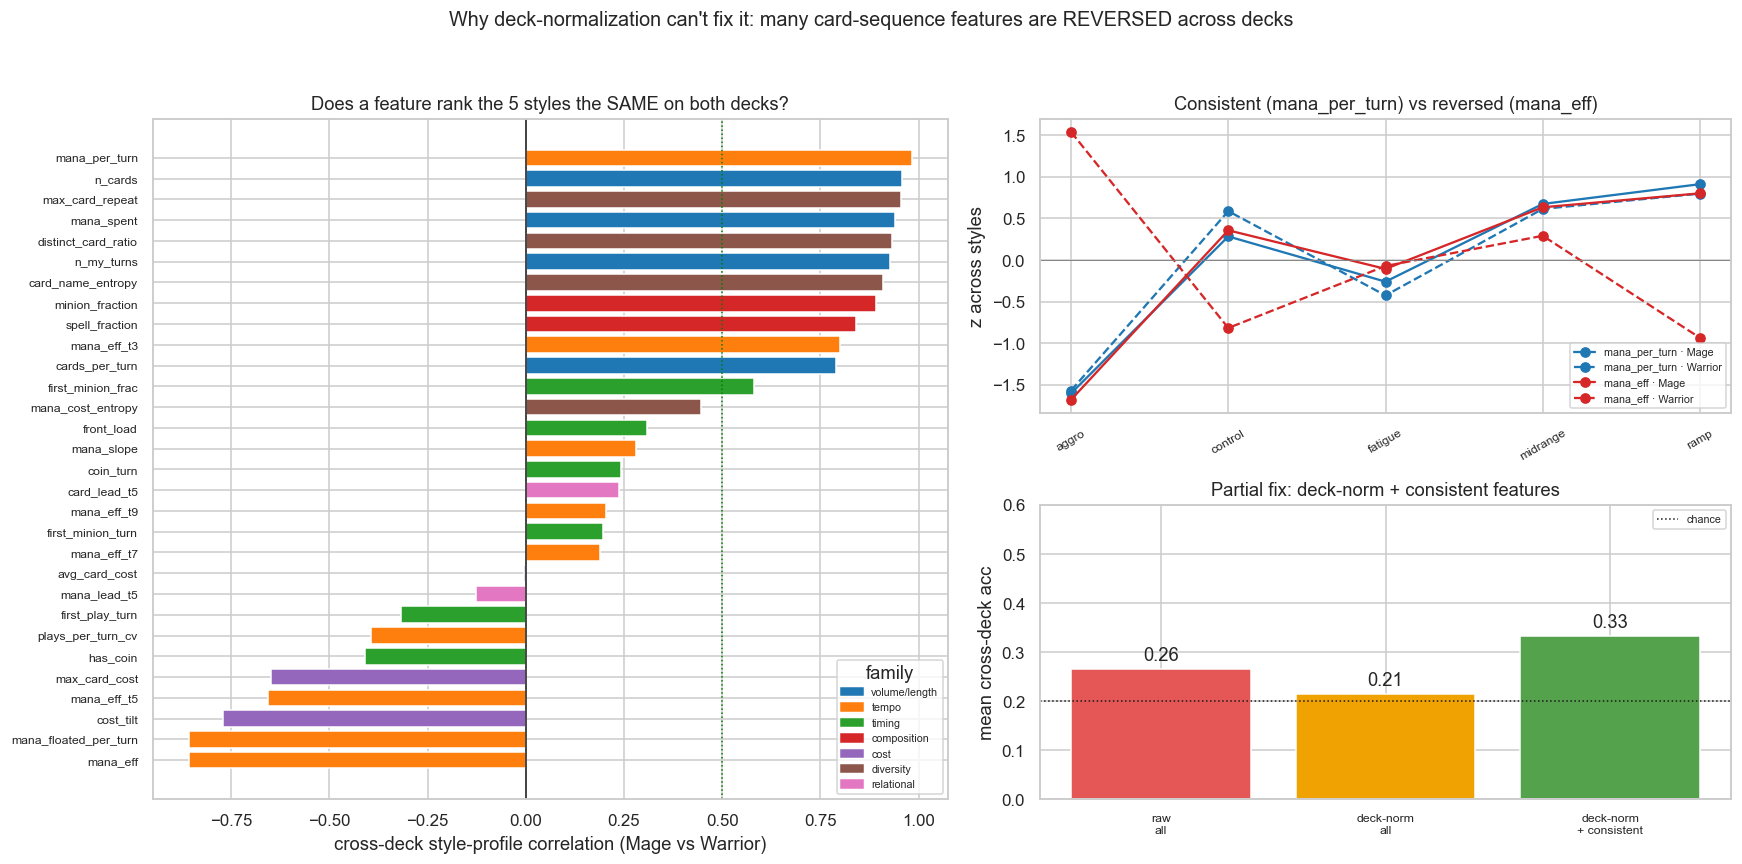

cross-deck-consistent features (profile corr > 0.5): 12/30
   first_minion_frac, cards_per_turn, mana_eff_t3, spell_fraction, minion_fraction, card_name_entropy, n_my_turns, distinct_card_ratio, mana_spent, max_card_repeat, n_cards, mana_per_turn
most reversed: mana_eff, mana_floated_per_turn, cost_tilt, mana_eff_t5 (corr -0.86, -0.86, -0.77, -0.66)


In [18]:
# C9 — cross-deck style-profile correlation (why) + the deck-norm + consistent-feature partial fix
A = df[df["deck"] == DA].groupby("style", observed=True)[FEATURES].mean().reindex(STYLE_ORDER)
B = df[df["deck"] == DB].groupby("style", observed=True)[FEATURES].mean().reindex(STYLE_ORDER)
corr = {}
for f in FEATURES:
    a, b = A[f].values, B[f].values
    corr[f] = np.nan if (np.nanstd(a) < 1e-9 or np.nanstd(b) < 1e-9) else np.corrcoef(a, b)[0, 1]
pc = pd.Series(corr).dropna().sort_values()
CONSISTENT = list(pc[pc > 0.5].index)

def mean_cross(frame, feats):
    return (cross_feats(frame, DA, DB, feats) + cross_feats(frame, DB, DA, feats)) / 2
fix = {"raw\nall": mean_cross(df, ANALYSIS_FEATURES),
       "deck-norm\nall": mean_cross(df_dz, ANALYSIS_FEATURES),
       "deck-norm\n+ consistent": mean_cross(df_dz, CONSISTENT)}

from matplotlib.patches import Patch
fig, axd = plt.subplot_mosaic([["corr", "ex"], ["corr", "fix"]], figsize=(16, 8),
                              gridspec_kw={"width_ratios": [1.15, 1]})
# left: per-feature cross-deck profile correlation, coloured by family
axd["corr"].barh(range(len(pc)), pc.values, color=[FAM_COLORS[FAMILY[f]] for f in pc.index])
axd["corr"].set_yticks(range(len(pc))); axd["corr"].set_yticklabels(pc.index, fontsize=8)
axd["corr"].axvline(0, color="k", lw=1); axd["corr"].axvline(0.5, color="green", ls=":", lw=1)
axd["corr"].set_xlabel("cross-deck style-profile correlation (Mage vs Warrior)")
axd["corr"].set_title("Does a feature rank the 5 styles the SAME on both decks?")
axd["corr"].legend(handles=[Patch(color=FAM_COLORS[k], label=k) for k in FAM_ORDER],
                   fontsize=7, loc="lower right", title="family")
# middle: one consistent vs one reversed feature profile
for feat, col in [("mana_per_turn", "#1f77b4"), ("mana_eff", "#d62728")]:
    for deck, ls in [(DA, "-"), (DB, "--")]:
        p = df[df["deck"] == deck].groupby("style", observed=True)[feat].mean().reindex(STYLE_ORDER)
        z = (p - p.mean()) / p.std()
        axd["ex"].plot(range(5), z.values, ls, color=col, marker="o",
                       label=f"{feat} · {'Mage' if deck == DA else 'Warrior'}")
axd["ex"].set_xticks(range(5)); axd["ex"].set_xticklabels(STYLE_ORDER, rotation=30, fontsize=8)
axd["ex"].axhline(0, color="gray", lw=.6); axd["ex"].set_ylabel("z across styles")
axd["ex"].legend(fontsize=7); axd["ex"].set_title("Consistent (mana_per_turn) vs reversed (mana_eff)")
# bottom-right: the partial fix
axd["fix"].bar(range(3), list(fix.values()), color=["#E45756", "#F0A202", "#54A24B"])
axd["fix"].bar_label(axd["fix"].containers[0], fmt="%.2f", padding=3)
axd["fix"].axhline(0.20, color="k", ls=":", lw=1, label="chance")
axd["fix"].set_xticks(range(3)); axd["fix"].set_xticklabels(list(fix), fontsize=8)
axd["fix"].set_ylim(0, 0.6); axd["fix"].set_ylabel("mean cross-deck acc")
axd["fix"].set_title("Partial fix: deck-norm + consistent features"); axd["fix"].legend(fontsize=7)
fig.suptitle("Why deck-normalization can't fix it: many card-sequence features are REVERSED across decks", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print(f"cross-deck-consistent features (profile corr > 0.5): {len(CONSISTENT)}/{len(pc)}")
print("  ", ", ".join(CONSISTENT))
print("most reversed:", ", ".join(pc.head(4).index), "(corr", ", ".join(f"{v:.2f}" for v in pc.head(4).values) + ")")

## Reading the deck end-to-end

1. **C1** — only the mana / timing / card-type metrics survive on public logs; ~21 of the V1–V4 set,
   plus 9 new sequence/relational metrics. The board, combat, hand, draw and hero-power metrics are lost.
2. **C2 + C3 + C4** — the survivors reconstruct and flag **aggro**, but *every* feature encodes the
   **deck** more than the **style**: composition/cost/diversity ≈ deck identity, volume/timing = the only
   (weak) transferable style tell.
3. **C5 + C6** — pooled over both decks, unsupervised clustering recovers the deck, not the style; yet
   *within* one deck, pooling games still sharpens the five styles — so the metrics carry signal, the
   problem is deck **bias**.
4. **C7** — the clincher: cross-deck transfer is near chance in both directions and pooling cannot fix it.
5. **C8 + C9** — the R6c domain-shift fix (per-deck z-scoring) does **not** rescue card-sequence transfer:
   many features are *reversed* across decks, not merely shifted, and no affine per-deck correction can
   straighten a reversal. Dropping the reversed features *and* normalizing gives only partial traction
   (mean cross-deck ≈ 0.26 → 0.33, still well below within-deck) — deck-entanglement is reduced, not solved.

**Bottom line.** From card sequences alone, play-style inference does not transfer across decks, and the
usual domain-shift correction only partially helps. This sharpens the
[`playstyle_SHOW_deck.ipynb`](playstyle_SHOW_deck.ipynb) result: the deck-agnostic edge V4 found came from
combat/board behaviour — precisely the signal that public play logs cannot observe. Recovering a
deck-agnostic style axis from public logs is the open future-work item.